In [1]:
import kagglehub
from pathlib import Path
import pandas as pd

# Download dataset (requires: pip install kagglehub; Kaggle account / API if prompted)
path = Path(kagglehub.dataset_download("yasserh/wine-quality-dataset"))
csv_path = next(path.rglob("*.csv"))
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace(" ", "_")

if "Id" in df.columns:
    df = df.drop(columns=["Id"])

X = df.drop(columns=["quality"])
y = df[["quality"]]

print("Path to dataset files:", path)
print("Using CSV:", csv_path.name)
print(df.shape)
print(df.head())


Path to dataset files: /Users/brandongao/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1
Using CSV: WineQT.csv
(1143, 12)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.

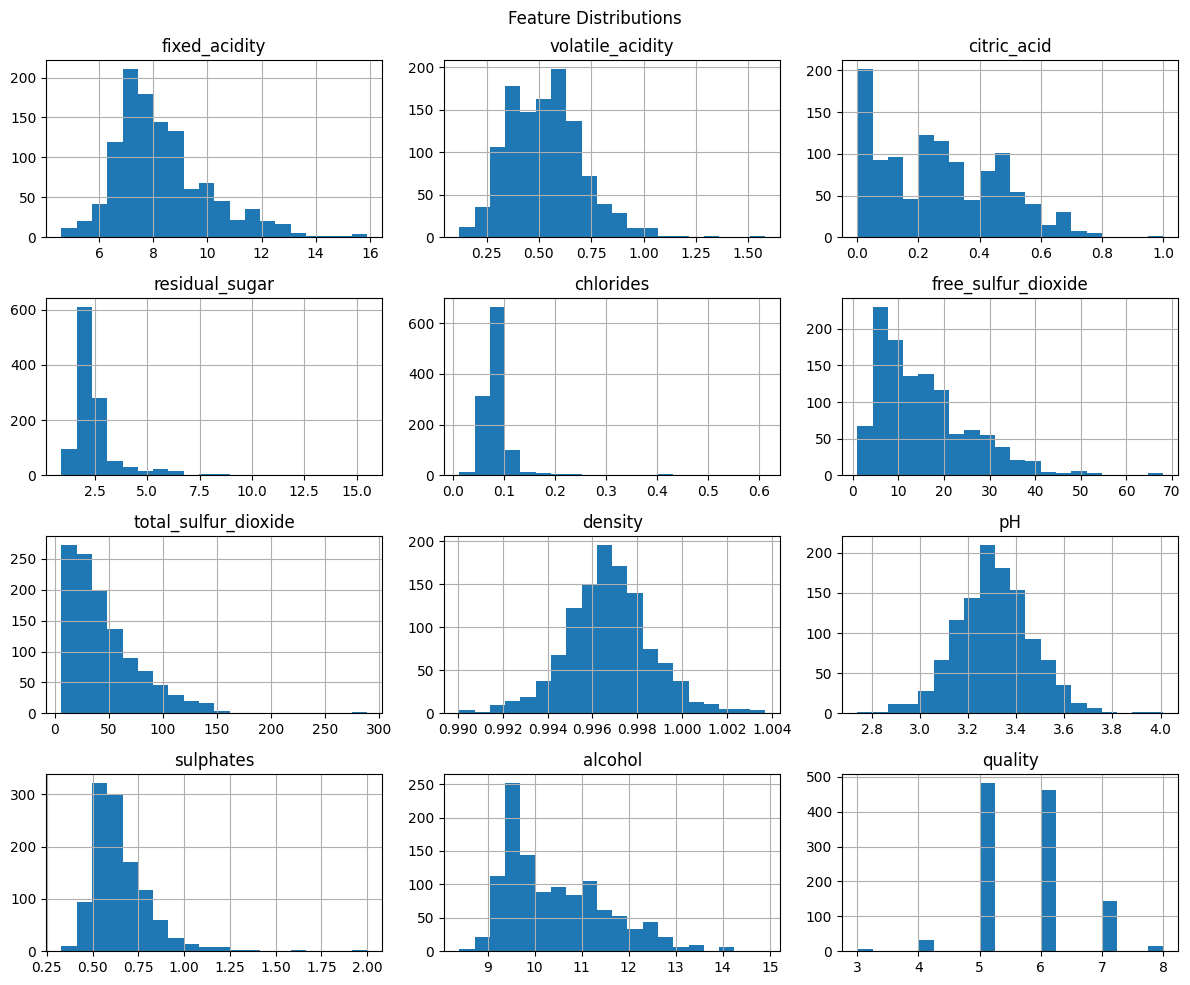

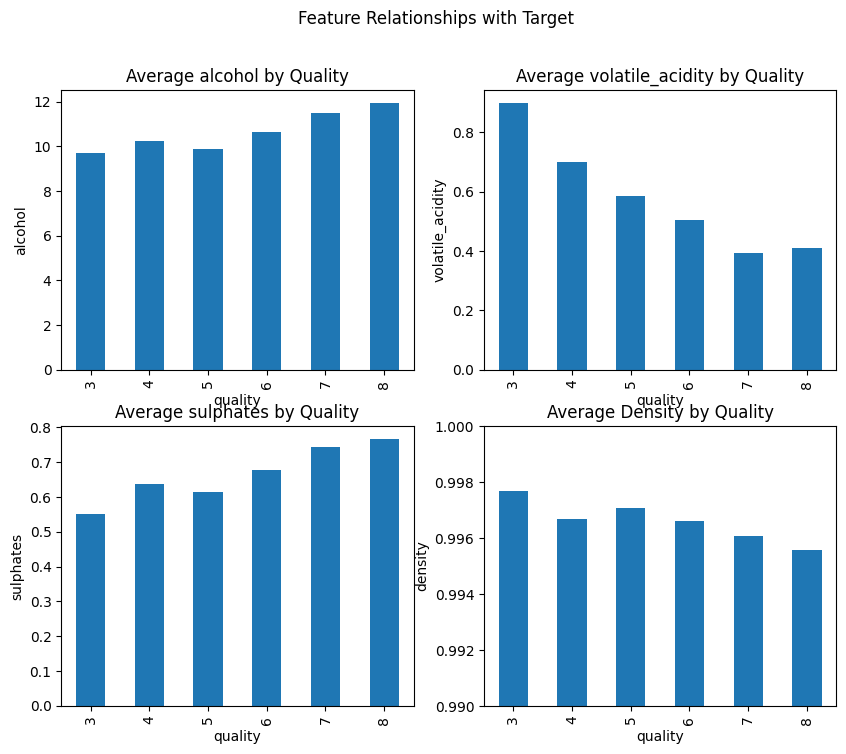

<Figure size 640x480 with 0 Axes>

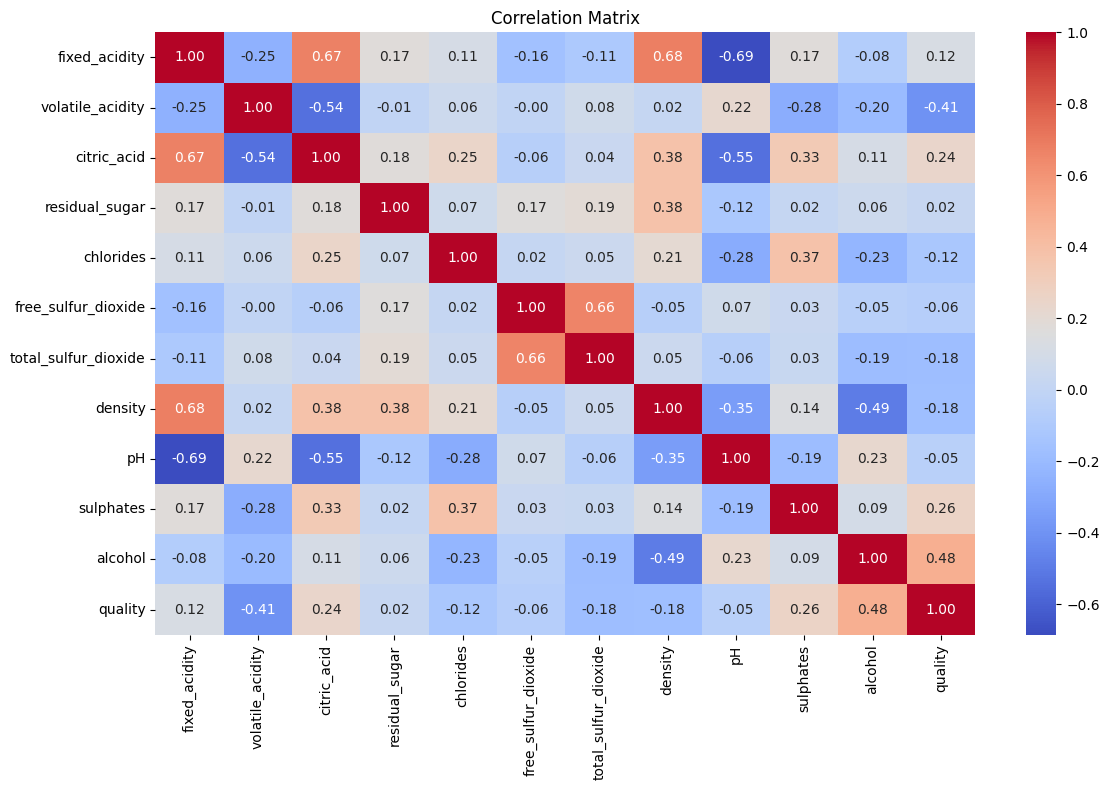

In [2]:
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd

# df
assert "df" in globals(), "Run the data-loading cell above first."

# 1. histogram
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

# 2. bar plot - relationships with target
important = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, feature in enumerate(important):
    df.groupby('quality')[feature].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Average {feature} by Quality')
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(feature)
plt.suptitle('Feature Relationships with Target')
# just for density, zoom in on the y axis
df.groupby('quality')['density'].mean().plot(kind='bar')
plt.title('Average Density by Quality')
plt.ylim(0.99, 1.00)  # zoom in
plt.show()
plt.tight_layout()
plt.show()

# 3. correlation matrix
plt.figure(figsize=(12, 8))
sb.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Cluster profile (means):
          alcohol  volatile_acidity  sulphates  density  quality
cluster                                                        
0          10.27              0.43       0.83     1.00     5.90
1           9.83              0.62       0.57     1.00     5.27
2          11.83              0.46       0.67     0.99     6.22


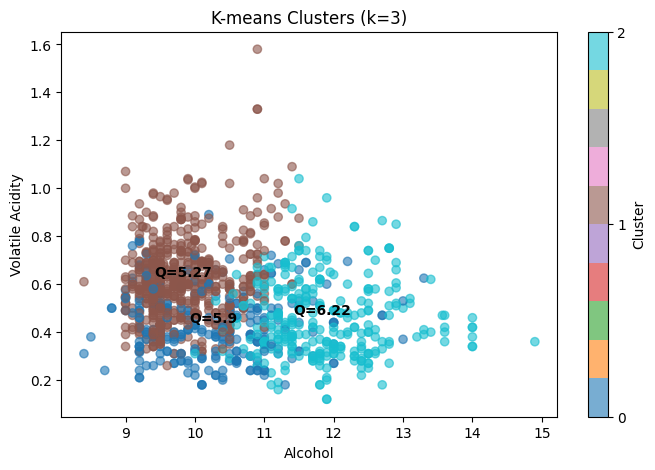

In [3]:
# Import libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Fill missing values
df.fillna(df.median(), inplace=True)

# Use the 4 features from your EDA
features = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
X_km = df[features]

# Scale the features
scaler = StandardScaler()
X_km_scaled = scaler.fit_transform(X_km)

# Fit K-means with k=3
km = KMeans(n_clusters=3, random_state=40, n_init=10)
df['cluster'] = km.fit_predict(X_km_scaled)

# give each cluster stats
profile = df.groupby('cluster')[['alcohol', 'volatile_acidity', 'sulphates', 'density', 'quality']].mean().round(2)
print("Cluster profile (means):\n", profile)


# give each cluster color
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['alcohol'], df['volatile_acidity'],c=df['cluster'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster', ticks=[0, 1, 2])
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.title('K-means Clusters (k=3)')

for cluster_id, row in profile.iterrows():
    plt.text(row['alcohol'], row['volatile_acidity'],
             f"Q={row['quality']}", fontsize=10, fontweight='bold', 
             ha='center', va='bottom', color='black')

plt.show()

,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.746725,1.000000,1.000000,0.748352,0.746725
1,3,0.902190,0.755459,0.894501,0.902190,0.727583,0.755459
2,5,0.884672,0.790393,0.855453,0.884672,0.743492,0.790393
3,7,0.865693,0.777293,0.831552,0.865693,0.723011,0.777293
4,9,0.861314,0.781659,0.824839,0.861314,0.714699,0.781659
5,11,0.861314,0.786026,0.825179,0.861314,0.722781,0.786026


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.733624,1.000000,1.000000,0.747710,0.733624
1,3,0.897810,0.759825,0.889153,0.897810,0.731275,0.759825
2,5,0.883212,0.768559,0.850695,0.883212,0.739692,0.768559
3,7,0.875912,0.768559,0.842203,0.875912,0.723606,0.768559
4,9,0.870073,0.764192,0.835228,0.870073,0.705971,0.764192
5,11,0.862774,0.777293,0.826719,0.862774,0.723011,0.777293


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.755459,1.000000,1.000000,0.772378,0.755459
1,3,0.897810,0.746725,0.888572,0.897810,0.724846,0.746725
2,5,0.881752,0.759825,0.849017,0.881752,0.726908,0.759825
3,7,0.875912,0.794760,0.842717,0.875912,0.745979,0.794760
4,9,0.859854,0.786026,0.823677,0.859854,0.722781,0.786026
5,11,0.859854,0.794760,0.823286,0.859854,0.737721,0.794760


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.759825,1.000000,1.000000,0.762217,0.759825
1,3,0.903650,0.759825,0.896449,0.903650,0.737018,0.759825
2,5,0.887591,0.755459,0.872580,0.887591,0.730715,0.755459
3,7,0.878832,0.790393,0.846485,0.878832,0.739344,0.790393
4,9,0.870073,0.781659,0.836997,0.870073,0.725333,0.781659
5,11,0.870073,0.781659,0.835616,0.870073,0.714699,0.781659


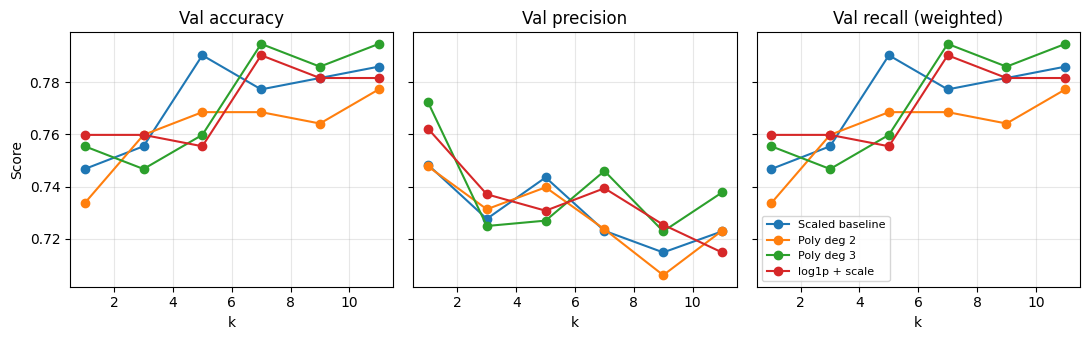

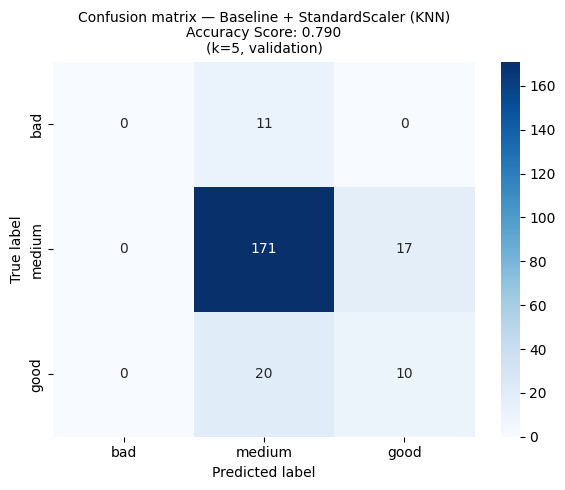

In [4]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score
import seaborn as sb

# Three quality buckets: bad (<5), medium ([5,7)), good (>=7)
y_bucket = np.select(
    [
        df["quality"].values < 5,(df["quality"].values >= 5) & (df["quality"].values < 7),df["quality"].values >= 7,
    ],
    [0, 1, 2],
    default=-1,
)

feature_cols = [
    "fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides","free_sulfur_dioxide","total_sulfur_dioxide","density","pH","sulphates","alcohol",
]
X = df[feature_cols]

# 60% train / 20% validation / 20% test
X_temp, X_test_new, y_temp, y_test_new = train_test_split(
    X,
    y_bucket,
    test_size=0.2,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
)

X_train = np.asarray(X_train, dtype=float)
X_val = np.asarray(X_val, dtype=float)

k_values = [1, 3, 5, 7, 9, 11]
# choose these odd values to prevent ties and i wanted 6 evenly spaced off values from very local/ flexible to a more structured/smooth model by the end which would test high bias/low variance ( stopped at 11 because there were only 11 features)

# Baseline: original features + StandardScaler (preprocessing)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

knn_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_results.append({
        "k": k,"train_acc": knn.score(X_train_scaled, y_train),
        "val_acc": knn.score(X_val_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_scaled), average="weighted", zero_division=0),
    })

# Polynomial degree 2: squared, then scale for KNN. Degree 2 adds squares and is a more complex model class, I wanted to test it out to see if pattern was better than the linear one
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

scaler_poly = StandardScaler()
X_train_poly2_scaled = scaler_poly.fit_transform(X_train_poly)
X_val_poly2_scaled = scaler_poly.transform(X_val_poly)

knn_results_poly = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly2_scaled, y_train)
    knn_results_poly.append({
        "k": k, "train_acc": knn.score(X_train_poly2_scaled, y_train),"val_acc": knn.score(X_val_poly2_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_poly2_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_poly2_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_poly2_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_poly2_scaled), average="weighted", zero_division=0),
    })

# Polynomial degree 3: degree 2 helped out a little bit in some of the features so I tried 3rd degree to compensate for the fact that there were 11 features and probably needed a higher order to map correctly
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_val_poly3 = poly3.transform(X_val)

scaler_poly3 = StandardScaler()
X_train_poly3_scaled = scaler_poly3.fit_transform(X_train_poly3)
X_val_poly3_scaled = scaler_poly3.transform(X_val_poly3)

knn_results_poly3 = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly3_scaled, y_train)
    knn_results_poly3.append({
        "k": k, "train_acc": knn.score(X_train_poly3_scaled, y_train),
        "val_acc": knn.score(X_val_poly3_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_poly3_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_poly3_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_poly3_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_poly3_scaled), average="weighted", zero_division=0),
    })

# Log transformation: a lot of the inputs are right skewed, the log will help compress larger values making it less sensitive to outliers.
X_train_log = np.log1p(np.maximum(X_train, 0.0))
X_val_log = np.log1p(np.maximum(X_val, 0.0)) # prevents negative logs

scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)

knn_results_log = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_log_scaled, y_train)
    knn_results_log.append({
        "k": k,"train_acc": knn.score(X_train_log_scaled, y_train),"val_acc": knn.score(X_val_log_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_log_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_log_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_log_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_log_scaled), average="weighted", zero_division=0),
    })

display(pd.DataFrame(knn_results))
display(pd.DataFrame(knn_results_poly))
display(pd.DataFrame(knn_results_poly3))
display(pd.DataFrame(knn_results_log))

transformations = [
    ("Scaled baseline", knn_results),("Poly deg 2", knn_results_poly),("Poly deg 3", knn_results_poly3),("log1p + scale", knn_results_log),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

stats = [
    (axes[0], "Val accuracy","val_acc"),(axes[1], "Val precision","val_precision"),(axes[2], "Val recall (weighted)","val_recall"),
]

for ax, title, key in stats:
    for name, rows in transformations:
        k     = [r["k"]  for r in rows]
        scores = [r[key]  for r in rows]
        ax.plot(k, scores, marker="o", label=name)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Score")
axes[-1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Confusion matrix for the baseline at its best k , k = 5
cm_labels = ["bad", "medium", "good"]

best_k = max(knn_results, key=lambda r: r["val_acc"])["k"]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_val_scaled)

cm  = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
acc = accuracy_score(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sb.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=cm_labels, yticklabels=cm_labels
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    f"Confusion matrix — Baseline + StandardScaler (KNN)\nAccuracy Score: {acc:.3f}\n(k={best_k}, validation)",
    fontsize=10,
)
plt.tight_layout()
plt.show()


In [5]:
# Logistic Regression (same 3-class labels and train/val split as KNN cell above)
from sklearn.linear_model import LogisticRegression

scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

C_values = [0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
lr_results = []
for C in C_values:
    lr = LogisticRegression(C=C, max_iter=5000, random_state=40)
    lr.fit(X_train_lr, y_train)
    lr_results.append(
        {
            "C": C,
            "train_acc": lr.score(X_train_lr, y_train),
            "val_acc": lr.score(X_val_lr, y_val),
        }
    )

display(pd.DataFrame(lr_results))


,C,train_acc,val_acc
0,0.01,0.842336,0.825328
1,0.10,0.864234,0.790393
2,0.50,0.864234,0.794760
3,1.00,0.864234,0.794760
4,10.00,0.862774,0.794760
5,100.00,0.862774,0.794760


In [6]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

feature_cols_reg = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]
Xr = df[feature_cols_reg].astype(float)
yr = df["quality"].astype(float)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    Xr, yr, test_size=0.2, random_state=40
)

scaler_r = StandardScaler()
Xtr_s = scaler_r.fit_transform(X_tr_r)
Xte_s = scaler_r.transform(X_te_r)

lin = LinearRegression()
lin.fit(Xtr_s, y_tr_r)
pred_lin = lin.predict(Xte_s)
print(
    "LinearRegression — MSE:",
    mean_squared_error(y_te_r, pred_lin),
    "R²:",
    r2_score(y_te_r, pred_lin),
)

alpha_values = [0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
print("\nRidge:")
for alpha in alpha_values:
    ridge = Ridge(alpha=alpha, random_state=40)
    ridge.fit(Xtr_s, y_tr_r)
    pred = ridge.predict(Xte_s)
    print(
        f"  alpha={alpha:<6} RMSE={mean_squared_error(y_te_r, pred) ** 0.5:.4f}  R²={r2_score(y_te_r, pred):.4f}"
    )

print("\nLasso:")
for alpha in alpha_values:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=40)
    lasso.fit(Xtr_s, y_tr_r)
    pred = lasso.predict(Xte_s)
    print(
        f"  alpha={alpha:<6} RMSE={mean_squared_error(y_te_r, pred) ** 0.5:.4f}  R²={r2_score(y_te_r, pred):.4f}"
    )


LinearRegression — MSE: 0.4298295002979642 R²: 0.324926959415228

Ridge:
  alpha=0.01   RMSE=0.6556  R²=0.3249
  alpha=0.1    RMSE=0.6556  R²=0.3249
  alpha=0.5    RMSE=0.6556  R²=0.3250
  alpha=1.0    RMSE=0.6555  R²=0.3251
  alpha=10.0   RMSE=0.6549  R²=0.3265
  alpha=100.0  RMSE=0.6503  R²=0.3359

Lasso:
  alpha=0.01   RMSE=0.6507  R²=0.3349
  alpha=0.1    RMSE=0.6604  R²=0.3151
  alpha=0.5    RMSE=0.8000  R²=-0.0052
  alpha=1.0    RMSE=0.8000  R²=-0.0052
  alpha=10.0   RMSE=0.8000  R²=-0.0052
  alpha=100.0  RMSE=0.8000  R²=-0.0052


,Model,α,Train MSE,Validation MSE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,Lasso,0.01,0.4173,0.3699,0.6460,0.6082,0.3790,0.3353
1,Ridge,100,0.4172,0.3710,0.6459,0.6091,0.3791,0.3332
2,Ridge,10,0.4151,0.3786,0.6443,0.6153,0.3821,0.3196
3,Ridge,1,0.4151,0.3799,0.6443,0.6163,0.3822,0.3173
4,Ridge,0.5,0.4151,0.3800,0.6443,0.6164,0.3822,0.3172
5,Ridge,0.1,0.4151,0.3800,0.6443,0.6165,0.3822,0.3171
6,Ridge,0.01,0.4151,0.3800,0.6443,0.6165,0.3822,0.3171
7,Linear Regression,none,0.4151,0.3800,0.6443,0.6165,0.3822,0.3171
8,Lasso,0.1,0.4525,0.3821,0.6727,0.6182,0.3265,0.3133
9,Lasso,0.5,0.6719,0.5565,0.8197,0.7460,0.0000,-0.0000


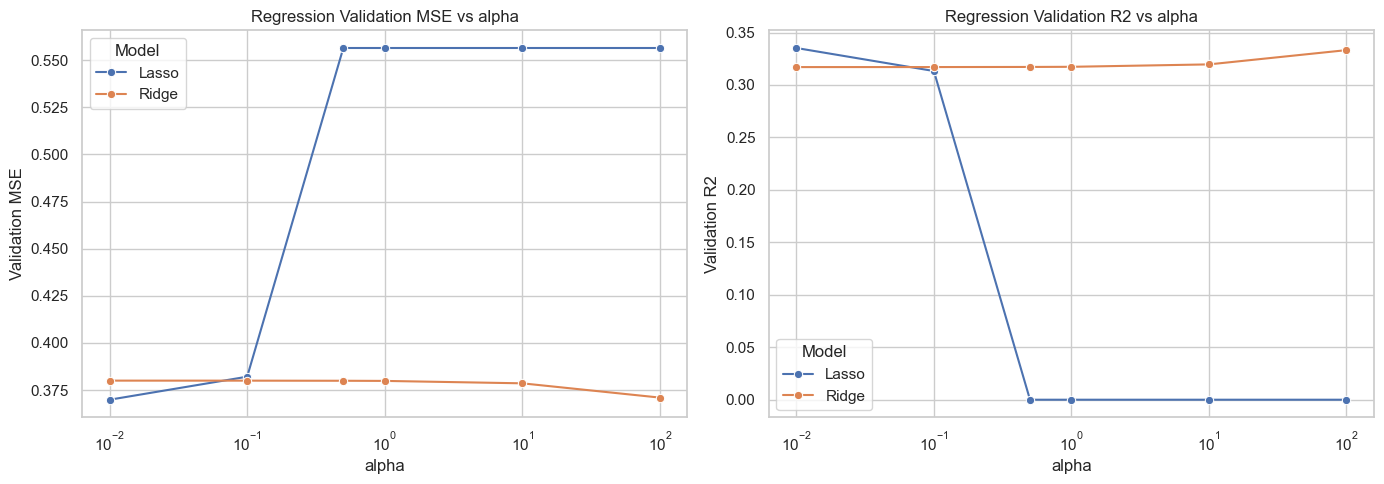

In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

sns.set_theme(style='whitegrid')

# Linear regression summary table
feature_cols_reg = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
    "density", "pH", "sulphates", "alcohol",
]
X_reg = df[feature_cols_reg].astype(float)
y_reg = df["quality"].astype(float)

X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42,
)

reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_val_reg_scaled = reg_scaler.transform(X_val_reg)

regression_rows = []
alpha_values = [0.01, 0.1, 0.5, 1, 10, 100]

def add_regression_metrics(model_name, alpha_label, model):
    model.fit(X_train_reg_scaled, y_train_reg)
    train_pred = model.predict(X_train_reg_scaled)
    val_pred = model.predict(X_val_reg_scaled)
    regression_rows.append({
        'Model': model_name,
        'α': alpha_label,
        'Train MSE': mean_squared_error(y_train_reg, train_pred),
        'Validation MSE': mean_squared_error(y_val_reg, val_pred),
        'Train RMSE': mean_squared_error(y_train_reg, train_pred) ** 0.5,
        'Validation RMSE': mean_squared_error(y_val_reg, val_pred) ** 0.5,
        'Train R2': r2_score(y_train_reg, train_pred),
        'Validation R2': r2_score(y_val_reg, val_pred),
    })

add_regression_metrics('Linear Regression', 'none', LinearRegression())

for alpha in alpha_values:
    add_regression_metrics('Ridge', alpha, Ridge(alpha=alpha))
    add_regression_metrics('Lasso', alpha, Lasso(alpha=alpha, max_iter=10000))

regression_results = pd.DataFrame(regression_rows)
regression_results = regression_results.sort_values(
    by=['Validation MSE', 'Validation R2'],
    ascending=[True, False],
).reset_index(drop=True)

display(regression_results.round(4))

# Linear regression plots
reg_plot_df = regression_results[regression_results['Model'].isin(['Ridge', 'Lasso'])].copy()
reg_plot_df['α'] = reg_plot_df['α'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=reg_plot_df, x='α', y='Validation MSE', hue='Model', marker='o', ax=axes[0])
sns.lineplot(data=reg_plot_df, x='α', y='Validation R2', hue='Model', marker='o', ax=axes[1])
axes[0].set_title('Regression Validation MSE vs alpha')
axes[1].set_title('Regression Validation R2 vs alpha')
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel('alpha')
plt.tight_layout()
plt.show()